# Group properties calculations
The notebook contains code for calculting group properties of the fish schools. The code plots the distribution for near neighbour distance, polarization, individual speed. We also plot 

In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from scipy import stats
from matplotlib.colors import LogNorm

In [5]:
#set working directory

os.chdir('/Users/jahanvitiwari/Desktop/mix species_GS16_codes/Manuscript')  #add working directory
print(os.getcwd())

/Users/jahanvitiwari/Desktop/mix species_GS16_codes/Manuscript


In [7]:
#Load dataset

data = np.load('MS_RB+TB_pol-vel-nnd.npz', allow_pickle=True)

vel = data['vel'] #velocity
pol = data['pol'] #polarization
nnd = data['nnd'] #near-neighbour distance

/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2627/1554809356.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


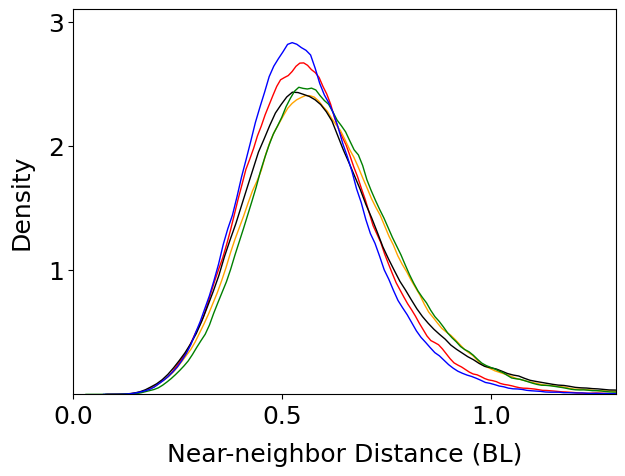

In [8]:
# Plot the near neighbour distance (NND) distribution 

fig = plt.figure(figsize=(7, 5))

colors = ['red', 'orange', 'black', 'green', 'blue']
labels = ['RB 16', 'RB 12 + TB 4', 'RB 8 + TB 8', 'RB 4 + TB 12', 'TB 16']
for i in range(5): # treatment
    nd = np.empty((0, 16))
    for j in range(5): #replicate
        nd = np.concatenate((nd, nnd[i][j]))

    sns.kdeplot(nd.ravel(), fill=False, color=colors[i], linewidth=1, label=labels[i])

plt.xticks(np.linspace(0, 1, 3), fontsize=18) 
plt.yticks(np.linspace(1, 3, 3), fontsize=18)  
plt.ylim(0,3.1)
plt.xlim(0,1.3)
plt.grid(False)
plt.xlabel("Near-neighbor Distance (BL)", fontsize=18, labelpad=10)
plt.ylabel("Density",  fontsize=18, labelpad=10)
#plt.legend(fontsize=18)
fig.show()
fig.savefig('near_neighbour_distance_kdeplot.png', dpi=300, bbox_inches='tight')

In [9]:
# Calculating mean, mode, median and std for near neighbour distance (NND)

labels = ['RB 16', 'RB 12 + TB 4', 'RB 8 + TB 8', 'RB 4 + TB 12', 'TB 16']

results = []

for i in range(5):  # treatment
    nd = np.concatenate([nnd[i][j] for j in range(5)])
    nd_flat = nd.ravel()
    nd_flat = nd_flat[~np.isnan(nd_flat)]

    # mode
    mode_result = stats.mode(nd_flat, keepdims=True)
    mode_val = mode_result.mode[0]

    results.append([
        labels[i],
        round(np.nanmean(nd_flat), 1),
        round(np.nanmedian(nd_flat), 1),
        round(mode_val, 1),
        round(np.nanstd(nd_flat), 1)
    ])

# Table
df = pd.DataFrame(results, columns=[
    "Treatment", "Mean", "Median", "Mode", "Std"
])

print(df.to_string(index=False))

   Treatment  Mean  Median  Mode  Std
       RB 16   0.6     0.6   0.2  0.2
RB 12 + TB 4   0.6     0.6   0.5  0.2
 RB 8 + TB 8   0.6     0.6   0.3  0.2
RB 4 + TB 12   0.6     0.6   0.6  0.2
       TB 16   0.6     0.5   0.5  0.2


In [ ]:
# GROUP ALIGNMENT (Group polarizaton)

In [10]:
# Calculating group polarisation

polarization = np.empty_like(pol)
for t in range(5):
    for r in range(5):
         polarization[r][t] = np.linalg.norm(pol[r][t], axis=1)

/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2627/4158992099.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


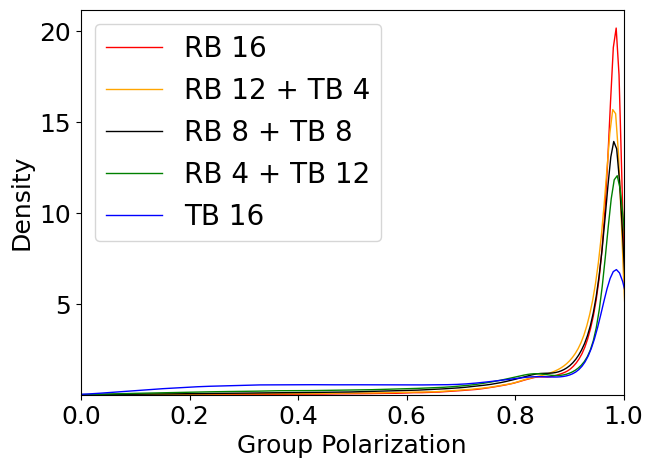

In [11]:
# Plotting group polarization

fig = plt.figure(figsize=(7, 5))

colors = ['red', 'orange', 'black', 'green','blue']
labels = ['RB 16', 'RB 12 + TB 4', 'RB 8 + TB 8', 'RB 4 + TB 12', 'TB 16']
for i in range(5): # treatment
    p = np.empty((1))
    for j in range(5): #replicate
        p = np.concatenate((p, polarization[j][i]))

    sns.kdeplot(p.ravel(), fill=False, color=colors[i], linewidth = 1, label=labels[i])


plt.xlim(0,1)
plt.xticks(fontsize=18) 
plt.yticks(np.linspace(5, 20, 4), fontsize=18)  
plt.grid(False)
plt.xlabel("Group Polarization", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.legend(fontsize=20, loc='upper left')
plt.tick_params(axis='both', labelsize=18)
fig.show()
fig.savefig('group polarization_kdeplot.png', dpi=300, bbox_inches='tight')

In [12]:
# Calculating mean, mode, median and std for group polarization

import numpy as np
import pandas as pd
import seaborn as sns

labels = ['RB 16', 'RB 12 + TB 4', 'RB 8 + TB 8', 'RB 4 + TB 12', 'TB 16']

results = []

for i in range(5):  # treatment
    p = np.concatenate([polarization[j][i] for j in range(5)])
    p_flat = p.ravel()
    p_flat = p_flat[~np.isnan(p_flat)]

    # ---- Mode (histogram) ----
    h, b = np.histogram(p_flat, bins=100, range=(0, 3))
    mode_idx = np.argmax(h)
    mode = (b[mode_idx] + b[mode_idx+1]) / 2

    # ---- Store results ----
    results.append([
        labels[i],
        round(mode, 1),
        round(np.nanmedian(p_flat), 1),
        round(np.nanmean(p_flat), 1),
        round(np.nanstd(p_flat), 1)
    ])

# Table
df = pd.DataFrame(results, columns=[
    "Treatment", "Mode", "Median", "Mean", "Std"
])

print(df.to_string(index=False))

   Treatment  Mode  Median  Mean  Std
       RB 16   1.0     1.0   0.9  0.1
RB 12 + TB 4   1.0     1.0   0.9  0.1
 RB 8 + TB 8   1.0     1.0   0.9  0.1
RB 4 + TB 12   1.0     1.0   0.9  0.2
       TB 16   1.0     0.9   0.8  0.3


In [13]:
# INDIVIDUAL SPEED

In [14]:
# Calculating individual speed

# create speed matrix with similar shape as vel where all the speed values is stored
# using linalg.norm, calculate the speed values for each time point for each trial

speed = np.empty_like(vel)
for t in range(5):
    for r in range(5):
        speed[r][t] = np.linalg.norm(vel[r][t], axis=2)

In [15]:
# exclude the zero values

for t in range(5):
    for r in range(5):
        speed[r][t][speed[r][t] < 0.001] = np.nan

speed.shape

(5, 5)

/Users/jahanvitiwari/miniconda3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Users/jahanvitiwari/miniconda3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/Users/jahanvitiwari/miniconda3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


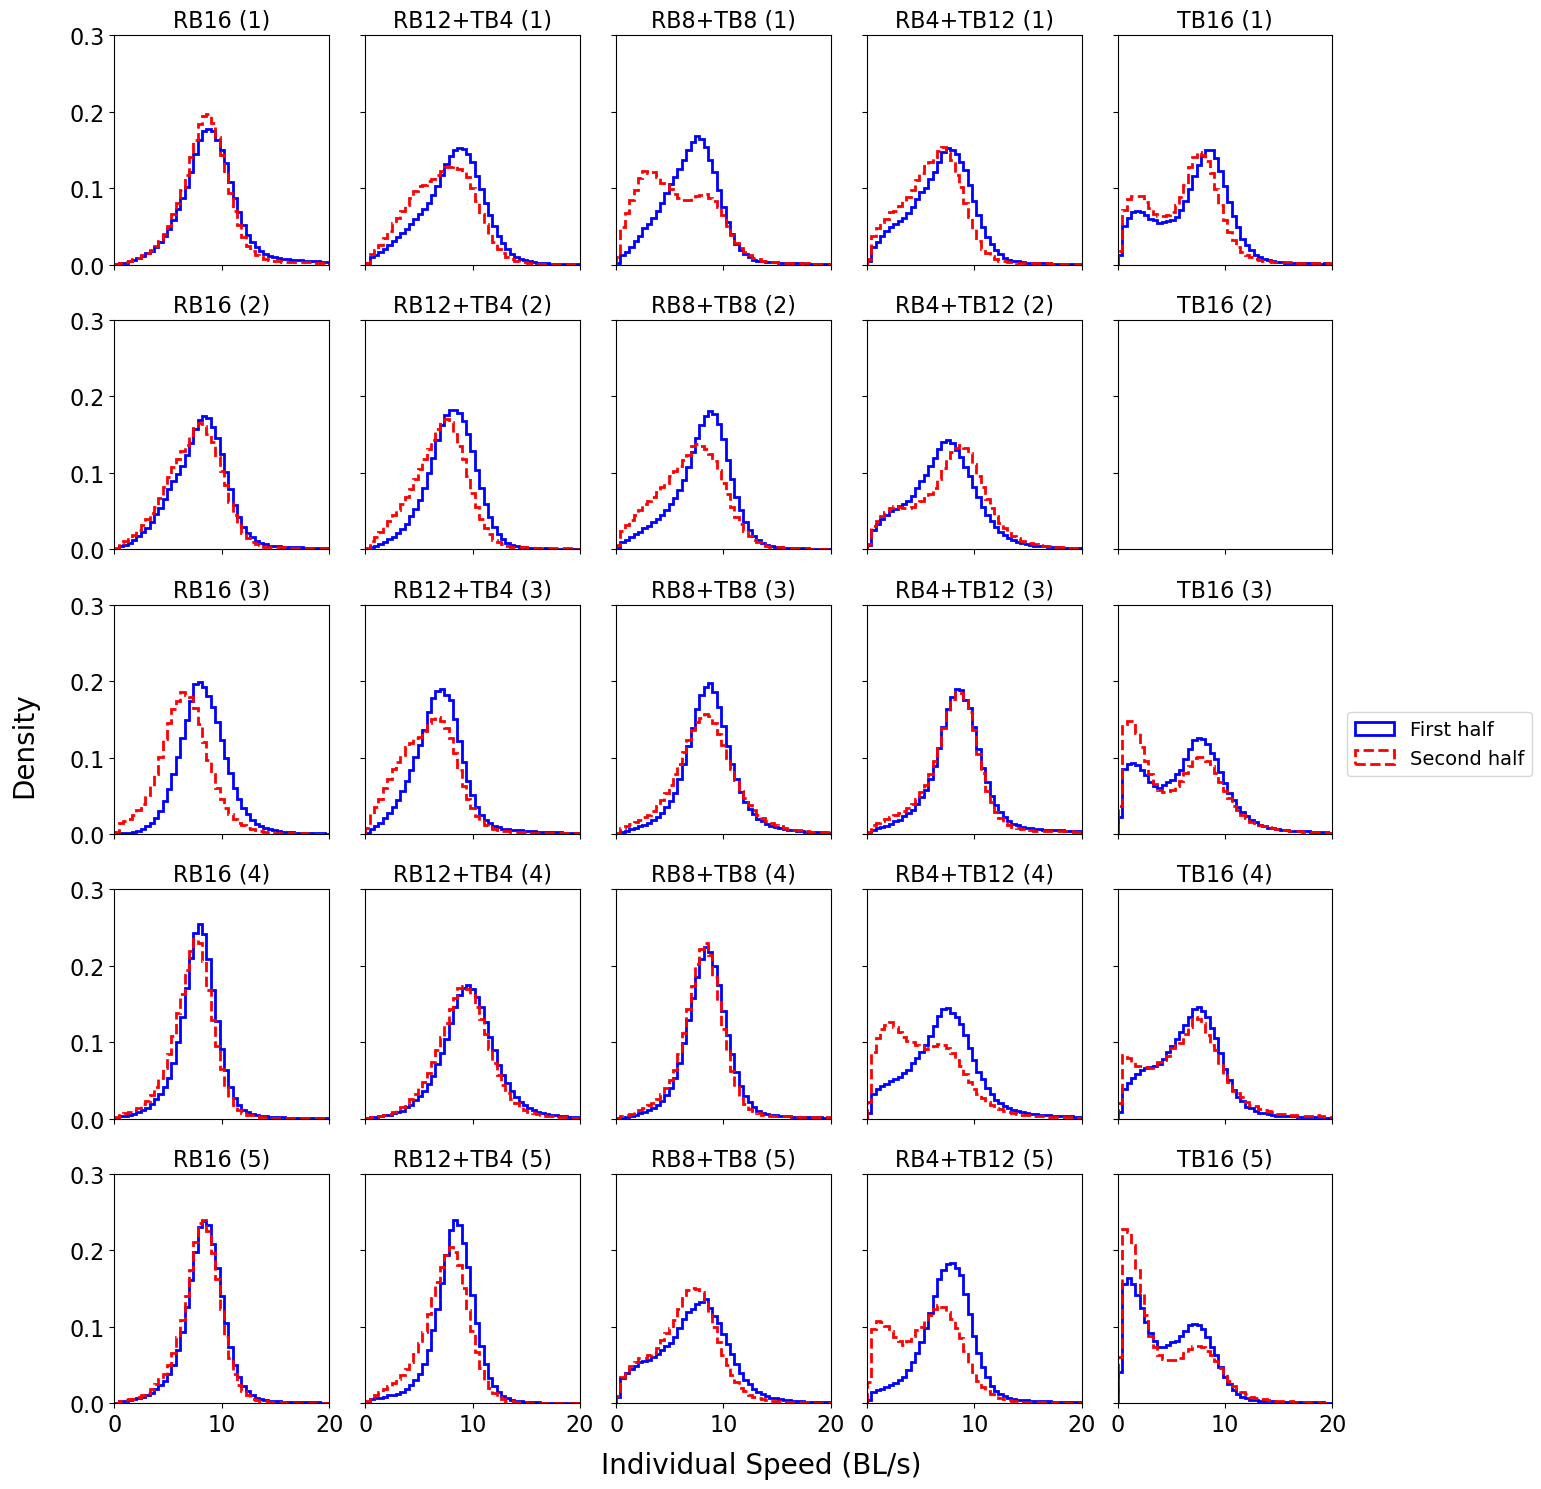

In [16]:
#Plotting first and second half of the trials for each replicates

replicates = ['1', '2', '3', '4', '5']
treatments = [
    'RB16',
    'RB12+TB4',
    'RB8+TB8',
    'RB4+TB12',
    'TB16'
]

fig, axes = plt.subplots(5, 5, figsize=(15, 15), sharex=True, sharey=True)

bins = np.linspace(0, 20, 50)

for i in range(5):          # replicates
    for j in range(5):      # treatments
        
        data = speed[i][j].ravel()
        n = len(data)
        
        first_half = data[:n//2]
        second_half = data[n//2:]
        
        # First half
        axes[i, j].hist(
            first_half,
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2,
            color='blue',
            label='First half' if (i == 0 and j == 0) else None
        )
        
        # Second half
        axes[i, j].hist(
            second_half,
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2,
            color='red',
            linestyle='--',
            label='Second half' if (i == 0 and j == 0) else None
        )
        
        # formatting
        axes[i, j].set_xlim(0, 20)
        axes[i, j].set_ylim(0, 0.3)
        axes[i, j].set_title(f'{treatments[j]} ({replicates[i]})', fontsize=16)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')
        axes[i, j].tick_params(axis='both', labelsize=16)

# global labels
fig.supxlabel('Individual Speed (BL/s)', fontsize=20)
fig.supylabel('Density', fontsize=20, x=-0.001)

# Adjust space on right for legend
plt.tight_layout(rect=[0, 0, 0.9, 1])

# Add legend outside
fig.legend(
    loc='center right',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=14
)

# Save and show
plt.show()
fig.savefig('first_vs_second_half_hist.png', dpi=300, bbox_inches='tight')

/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/3145345558.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


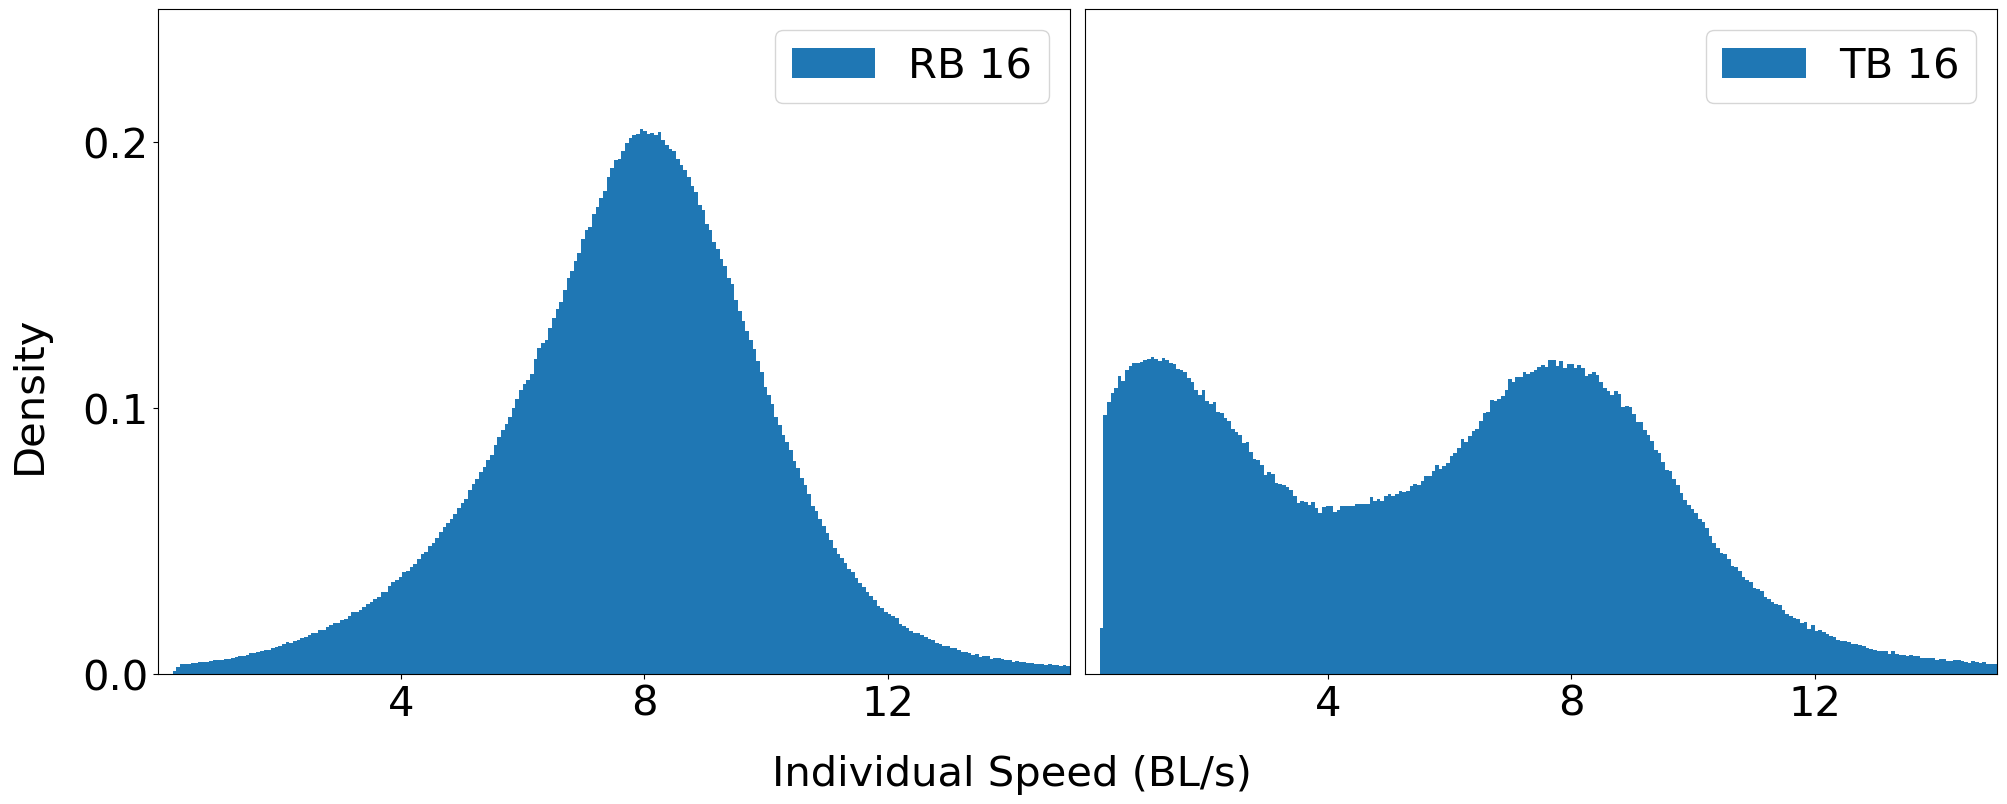

In [38]:
# Individual speed plot for single species trials 

speed_pooled = []
for i in range(5):
    s = np.empty ((0,16))
    for j in range(5):
        s = np.concatenate((s, speed[j][i]))

    speed_pooled.append(s)

hist_rb16, bins = np.histogram(speed_pooled[0].ravel(), bins=100, density=True, range=(0, 30))
hist_tb16, bins = np.histogram(speed_pooled[4].ravel(), bins=100, density=True, range=(0, 30))
                                                        
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax[0].hist(speed_pooled[0].ravel(), bins=500, density=True, range=(0, 30), label = 'RB 16', linewidth=4)
ax[1].hist(speed_pooled[4].ravel(), bins=500, density=True, range=(0, 30), label = 'TB 16', linewidth=4)

for i in range(2):                                                
    ax[i].set_ylim(0, 0.25)
    ax[i].set_xlim(0, 15)
    ax[i].set_xlabel('')
    if i == 0:
        ax[i].set_yticks(np.linspace(0, 0.2, 3))
        ax[i].set_ylabel('')
    else:
        ax[i].set_yticks([])
        ax[i].set_ylabel('')
    ax[i].set_xticks(np.linspace(4, 12, 3))
    ax[i].tick_params(axis='both', labelsize=30)
    ax[i].legend(fontsize=30, loc='upper right') 

fig.supxlabel('Individual Speed (BL/s)', fontsize=30, y=0.0001)
fig.supylabel('Density', fontsize=30, x=-0.001)

fig.savefig('individual_speed_gs16_.png', dpi=300, bbox_inches='tight')
fig.tight_layout()
fig.show()

/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/336346821.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


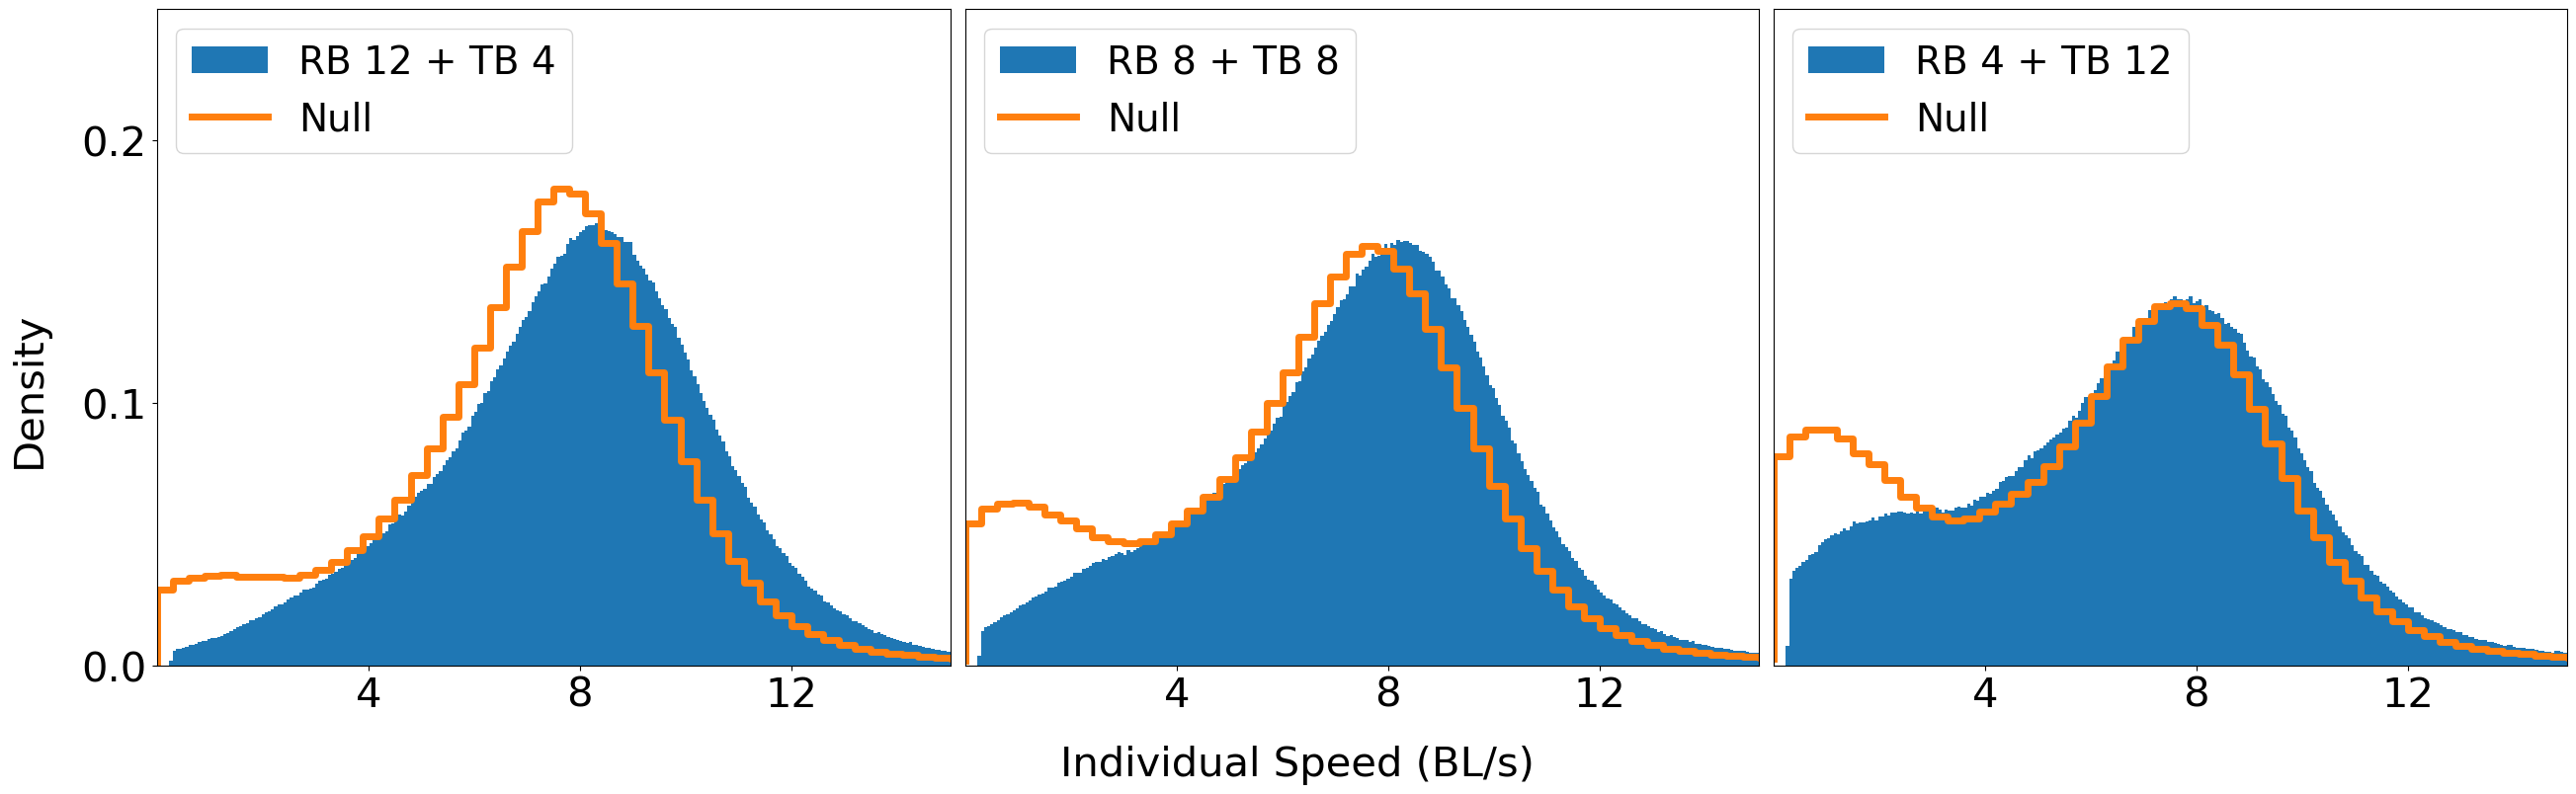

In [40]:
# Individual speed plot for mixed species trials with null 

speed_pooled = []
for i in range(5):
    s = np.empty ((0,16))
    for j in range(5):
        s = np.concatenate((s, speed[j][i]))

    speed_pooled.append(s)

hist_rb16, bins = np.histogram(speed_pooled[0].ravel(), bins=100, density=True, range=(0, 30))
hist_tb16, bins = np.histogram(speed_pooled[4].ravel(), bins=100, density=True, range=(0, 30))
hist_rb4, bins = np.histogram(speed_pooled[3].ravel(), bins=100, density=True, range=(0, 30))
hist_rb8, bins = np.histogram(speed_pooled[2].ravel(), bins=100, density=True, range=(0, 30))
hist_rb12, _ = np.histogram(speed_pooled[1].ravel(), bins=100, density=True, range=(0, 30))
                                                        
fig, ax = plt.subplots(1, 3, figsize=(26, 8))

ax[0].hist(speed_pooled[1].ravel(), bins=500, density=True, range=(0, 30), label = 'RB 12 + TB 4', linewidth=4)
ax[1].hist(speed_pooled[2].ravel(), bins=500, density=True, range=(0, 30), label = 'RB 8 + TB 8', linewidth=4)
ax[2].hist(speed_pooled[3].ravel(), bins=500, density=True, range=(0, 30), label = 'RB 4 + TB 12', linewidth=4)

ax[0].step(bins[:100], .75 * hist_rb16 + .25 * hist_tb16, label = 'Null',  linewidth=5)
ax[1].step(bins[:100], .5 * hist_rb16 + .5 * hist_tb16, label = 'Null',  linewidth=5)
ax[2].step(bins[:100], .25 * hist_rb16 + .75 * hist_tb16, label = 'Null', linewidth=5)

for i in range(3):                                                
    ax[i].set_ylim(0, 0.25)
    ax[i].set_xlim(0, 15)
    ax[i].set_xlabel('')
    if i == 0:
        ax[i].set_yticks(np.linspace(0, 0.2, 3))
        ax[i].set_ylabel('')
    else:
        ax[i].set_yticks([])
        ax[i].set_ylabel('')
    ax[i].set_xticks(np.linspace(4, 12, 3))
    ax[i].tick_params(axis='both', labelsize=30)
    ax[i].legend(loc='upper left', fontsize=28, frameon=True)

fig.supxlabel('Individual Speed (BL/s)', fontsize=30, y=0.0001)
fig.supylabel('Density', fontsize=30, x=-0.001)

fig.savefig('individual_speed_gs16_null.png', dpi=300, bbox_inches='tight')
fig.tight_layout()
fig.show()

In [35]:
# Calculating mean, mode, median and std for individual speed distribution

labels = ['RB 16', 'RB 12 + TB 4', 'RB 8 + TB 8', 'RB 4 + TB 12', 'TB 16']

results = []

for i in range(5):
    s = np.concatenate([speed[j][i] for j in range(5)])
    s_flat = s.ravel()

    # histogram mode
    h, b = np.histogram(s_flat, bins=100, range=(0, 20))
    mode_idx = np.argmax(h)
    mode = (b[mode_idx] + b[mode_idx+1]) / 2

    results.append([
        labels[i],
        round(mode, 1),
        round(np.nanmedian(s_flat), 1),
        round(np.nanmean(s_flat), 1),
        round(np.nanstd(s_flat), 1)
    ])

# ---- Create table ----
df = pd.DataFrame(results, columns=[
    "Treatment", "Mode", "Median", "Mean", "Std"
])

print(df.to_string(index=False))

   Treatment  Mode  Median  Mean  Std
       RB 16   7.9     8.0   8.0  3.0
RB 12 + TB 4   8.3     8.1   8.0  3.0
 RB 8 + TB 8   8.3     7.8   7.6  3.3
RB 4 + TB 12   7.7     7.1   7.1  3.8
       TB 16   1.1     6.2   6.0  4.1


/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/62769454.py:17: RuntimeWarning: Mean of empty slice
  s = np.nanmean(s_raw, axis=1)        # mean speed per frame
/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/62769454.py:17: RuntimeWarning: Mean of empty slice
  s = np.nanmean(s_raw, axis=1)        # mean speed per frame
/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/62769454.py:17: RuntimeWarning: Mean of empty slice
  s = np.nanmean(s_raw, axis=1)        # mean speed per frame
/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/62769454.py:17: RuntimeWarning: Mean of empty slice
  s = np.nanmean(s_raw, axis=1)        # mean speed per frame
/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_2779/62769454.py:17: RuntimeWarning: Mean of empty slice
  s = np.nanmean(s_raw, axis=1)        # mean speed per frame


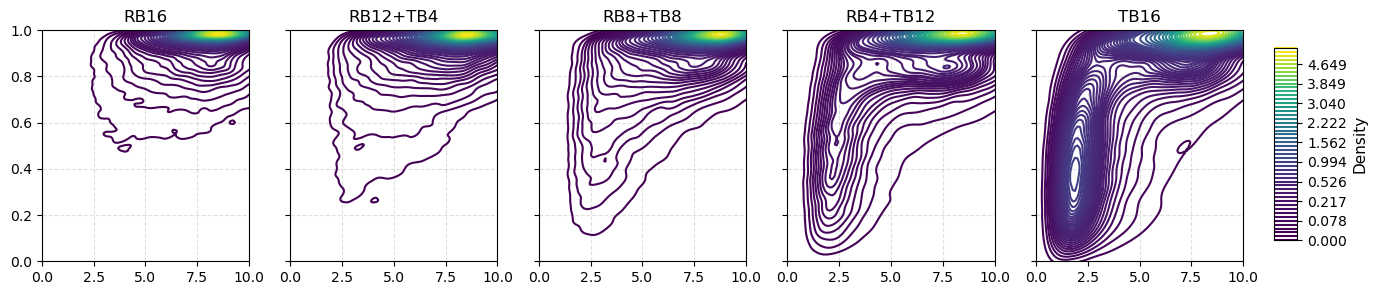

In [36]:
#plotting speed and polarization relationship

fig, axes = plt.subplots(1, 5, figsize=(15.5, 3), sharey=True)

fig.subplots_adjust(right=0.90)

mappables = []

for i in range(5):
    p_all, s_all = [], []

    for j in range(5):
        p = np.asarray(polarization[j][i]).ravel()

        s_raw = np.asarray(speed[j][i])      # (frames, 16)
        s = np.nanmean(s_raw, axis=1)        # mean speed per frame

        n = min(len(p), len(s))
        mask = np.isfinite(p[:n]) & np.isfinite(s[:n])

        if np.any(mask):
            p_all.append(p[:n][mask])
            s_all.append(s[:n][mask])

    if len(p_all) == 0:
        axes[i].set_title(f'{treatments[i]}\n(no data)')
        continue

    p_all = np.concatenate(p_all)
    s_all = np.concatenate(s_all)

    kde = sns.kdeplot(
        x=s_all,
        y=p_all,
        ax=axes[i],
        cmap='viridis',
        levels=50,
        thresh=0.0 
    )

    mappables.append(kde.collections[0])

    axes[i].set_xlim(0, 10)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(treatments[i])
    axes[i].grid(True, linestyle='--', alpha=0.4)

fig.supxlabel('')
fig.supylabel('')


# colorbar
cax = fig.add_axes([0.92, 0.18, 0.015, 0.64])
cbar = fig.colorbar(mappables[0], cax=cax)
cbar.set_label('Density', fontsize=11)

plt.savefig(
    'speed_polarization.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
